In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision.datasets import FashionMNIST
from torchmetrics import Accuracy, ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
from timeit import default_timer as timer
import math
import matplotlib.pyplot as plt


In [3]:
train_data = FashionMNIST(root="train_data", download=True, train=True, transform=ToTensor())
test_data = FashionMNIST(root="test_data", download=True, train=False, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.0MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.0MB/s]


In [4]:
len(train_data)

60000

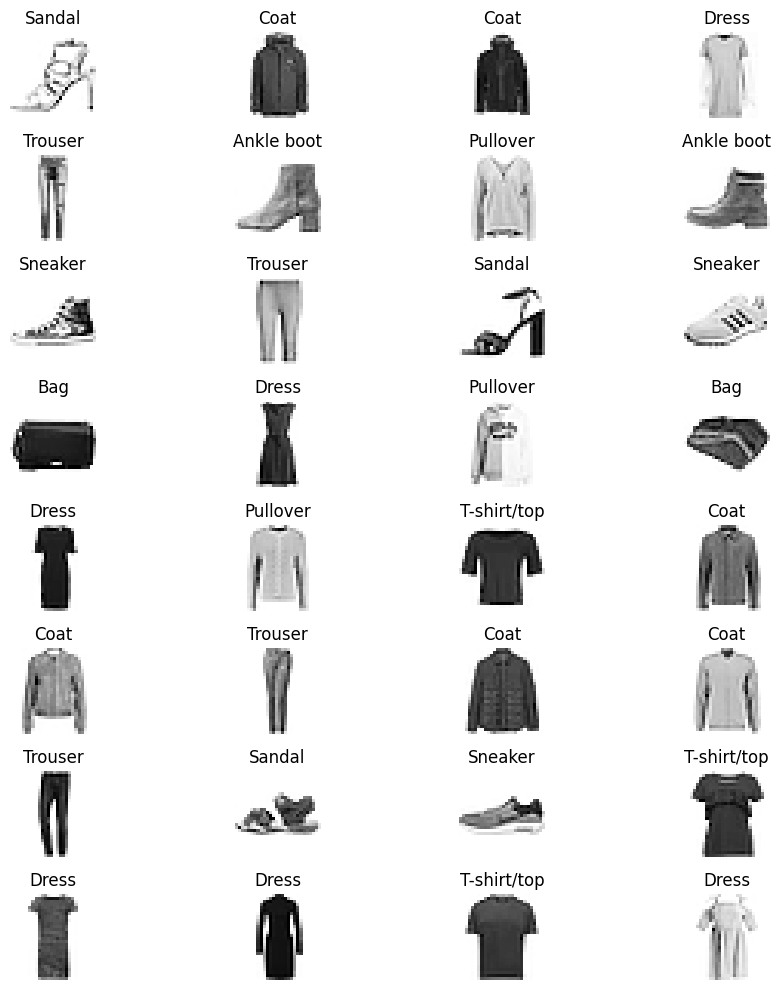

In [5]:
random_indices = torch.randint(0, len(train_data), size=(32,))
fig, ax = plt.subplots(nrows=math.ceil(random_indices.shape[0] / 4), ncols=4, figsize=(10,10))
ax = ax.flatten()
for index, axis in zip(random_indices, ax):
  axis.imshow(train_data.data[index], cmap=plt.cm.Greys)
  axis.set_title(f"{train_data.classes[train_data.targets[index]]}")
  axis.axis("off")

plt.tight_layout()

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
labels_list = train_data.classes

In [7]:
train_dataloader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=32, shuffle=True)

### First Regular Neural Network Model (Fully-Connected Perceptron)

In [8]:
class Model0(nn.Module):
  def __init__(self, input_features, hidden_units, output_features):
    super().__init__()
    self.input_features = input_features
    self.hidden_units = hidden_units
    self.output_features = output_features
    self.layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=self.input_features, out_features=self.hidden_units),
        nn.Linear(in_features=self.hidden_units, out_features=len(labels_list))
    )

  def forward(self, X):
    return self.layers(X)

In [9]:
dims = list(train_data[0][0].shape)

In [10]:
input_features = 1
for dim in dims:
  input_features *= dim


In [11]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model0 = Model0(input_features=input_features, hidden_units=64, output_features=len(labels_list)).to(device)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model0.parameters(), lr=0.001)

In [13]:
def train_model(model, dataloader, loss_fn, optimizer, device):
  train_loss = 0
  acc = Accuracy(task="multiclass", num_classes=len(labels_list)).to(device)
  total_samples = 0
  model.train()
  for batch_num, batch_data in enumerate(dataloader):
    X, y = batch_data[0], batch_data[1]
    X, y = X.to(device), y.to(device)

    y_hat_logits = model(X)
    y_hat_preds = torch.argmax(torch.softmax(y_hat_logits, dim=1), dim=1)

    loss = loss_fn(y_hat_logits, y)
    train_loss += loss.item() * X.shape[0]

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    total_samples += X.shape[0]
    acc.update(y_hat_preds, y)

    if batch_num % 1000 == 0 or batch_num == len(dataloader) - 1:
      print(f"Training on batch: {batch_num} / {len(dataloader) - 1}")

  train_loss = train_loss / total_samples
  accuracy = acc.compute().cpu().numpy().item() * 100
  acc.reset()

  return {"model": model.__class__.__name__, "train_loss": train_loss, "train_acc": accuracy}

In [14]:
def eval_model(model, dataloader, loss_fn, device):
  test_loss = 0
  acc = Accuracy(task="multiclass", num_classes=len(labels_list)).to(device)
  total_samples = 0
  model.eval()
  for batch in dataloader:
    X, y = batch[0], batch[1]
    X, y = X.to(device), y.to(device)

    with torch.inference_mode():
      y_hat_logits = model(X)
      y_hat_preds = torch.argmax(torch.softmax(y_hat_logits, dim=1), dim=1)

      loss = loss_fn(y_hat_logits, y)
      test_loss += loss.item() * X.shape[0]

    total_samples += X.shape[0]
    acc.update(y_hat_preds, y)

  test_loss = test_loss / total_samples
  accuracy = acc.compute().cpu().numpy().item() * 100
  acc.reset()

  return {"model": model.__class__.__name__, "test_loss": test_loss, "test_acc": accuracy}

In [15]:
def print_the_time(start, end, device):
  total_time = end - start
  print(f"Total training time: {total_time:.2f} on device {device}")
  return total_time

In [16]:
epochs = 20
for epoch in range(epochs):
  time_start = timer()
  train_dict_model0 = train_model(model0, train_dataloader, loss_fn, optimizer, device)
  time_end = timer()
  print_the_time(time_start, time_end, str(next(model0.parameters()).device))
  test_dict_model0 = eval_model(model0, test_dataloader, loss_fn, device)

  if epoch % 5 == 0 or epoch == epochs - 1:
    print("Report:")
    print(f"Epoch: {epoch}")
    print(f"Model name: {train_dict_model0["model"]} | Training loss: {train_dict_model0["train_loss"]} | Training Accuracy: {train_dict_model0["train_acc"]}")
    print(f"Model name: {test_dict_model0["model"]} | Test loss: {test_dict_model0["test_loss"]} | Test Accuracy: {test_dict_model0["test_acc"]}")

Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 11.16 on device cuda:0
Report:
Epoch: 0
Model name: Model0 | Training loss: 0.5453487912575404 | Training Accuracy: 81.05499744415283
Model name: Model0 | Test loss: 0.4926593210220337 | Test Accuracy: 82.77000188827515
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.85 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.57 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.87 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 14.52 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.31 on device cuda:0

### Fully-Connected Perceptron with non-linear Activation Function

In [17]:
class Model1(nn.Module):
  def __init__(self, input_features, hidden_units ,output_features):
    super().__init__()
    self.input_features = input_features
    self.hidden_units = hidden_units
    self.output_features = output_features
    self.layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=self.input_features, out_features=self.hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=self.hidden_units, out_features=self.output_features)
    )

  def forward(self, X):
    return self.layers(X)

In [18]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model1 = Model1(input_features=input_features, hidden_units=64, output_features=len(labels_list)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model1.parameters(), lr=0.001)

In [19]:
epochs = 20
for epoch in range(epochs):
  time_start = timer()
  train_dict_model1 = train_model(model1, train_dataloader, loss_fn, optimizer, device)
  time_end = timer()
  print_the_time(time_start, time_end, str(next(model0.parameters()).device))
  test_dict_model1 = eval_model(model1, test_dataloader, loss_fn, device)

  if epoch % 5 == 0 or epoch == epochs - 1:
    print("Report:")
    print(f"Epoch: {epoch}")
    print(f"Model name: {train_dict_model1["model"]} | Training loss: {train_dict_model1["train_loss"]} | Training Accuracy: {train_dict_model1["train_acc"]}")
    print(f"Model name: {test_dict_model1["model"]} | Test loss: {test_dict_model1["test_loss"]} | Test Accuracy: {test_dict_model1["test_acc"]}")


Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.61 on device cuda:0
Report:
Epoch: 0
Model name: Model1 | Training loss: 0.541227241162459 | Training Accuracy: 81.23499751091003
Model name: Model1 | Test loss: 0.45902449033260345 | Test Accuracy: 83.89999866485596
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.47 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.47 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.68 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.47 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 10.36 on device cuda:0

In [20]:
class Model2(nn.Module):
  def __init__(self, in_channels:int, hidden_units:int, output_classes_num:int):
    super().__init__()
    self.in_chanells = in_channels
    self.hidden_units = hidden_units
    self.output_classes_num = output_classes_num
    self.conv1_block = nn.Sequential(
        nn.Conv2d(in_channels=self.in_chanells, out_channels=self.hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=self.hidden_units, out_channels=self.hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.conv2_block = nn.Sequential(
        nn.Conv2d(in_channels=self.hidden_units, out_channels=self.hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=self.hidden_units, out_channels=self.hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 7 * 7, out_features=self.output_classes_num)
    )

  def forward(self, x):
    x = self.conv1_block(x)
    x = self.conv2_block(x)
    x = self.classifier(x)
    return x

In [21]:
image_channels, image_height, image_width = dims

In [22]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model2 = Model2(in_channels=image_channels, hidden_units=10, output_classes_num=len(labels_list)).to(device)

In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

In [24]:
epochs = 20
for epoch in range(epochs):
  time_start = timer()
  train_dict_model2 = train_model(model2, train_dataloader, loss_fn, optimizer, device)
  time_end = timer()
  print_the_time(time_start, time_end, str(next(model0.parameters()).device))
  test_dict_model2 = eval_model(model2, test_dataloader, loss_fn, device)

  if epoch % 5 == 0 or epoch == epochs - 1:
    print("Report:")
    print(f"Epoch: {epoch}")
    print(f"Model name: {train_dict_model2["model"]} | Training loss: {train_dict_model2["train_loss"]} | Training Accuracy: {train_dict_model2["train_acc"]}")
    print(f"Model name: {test_dict_model2["model"]} | Test loss: {test_dict_model2["test_loss"]} | Test Accuracy: {test_dict_model2["test_acc"]}")

Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 13.07 on device cuda:0
Report:
Epoch: 0
Model name: Model2 | Training loss: 0.5460114226857821 | Training Accuracy: 80.17333149909973
Model name: Model2 | Test loss: 0.41314908666610717 | Test Accuracy: 84.64000225067139
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 12.55 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 12.82 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 12.56 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 12.65 on device cuda:0
Training on batch: 0 / 1874
Training on batch: 1000 / 1874
Training on batch: 1874 / 1874
Total training time: 12.62 on device cuda:

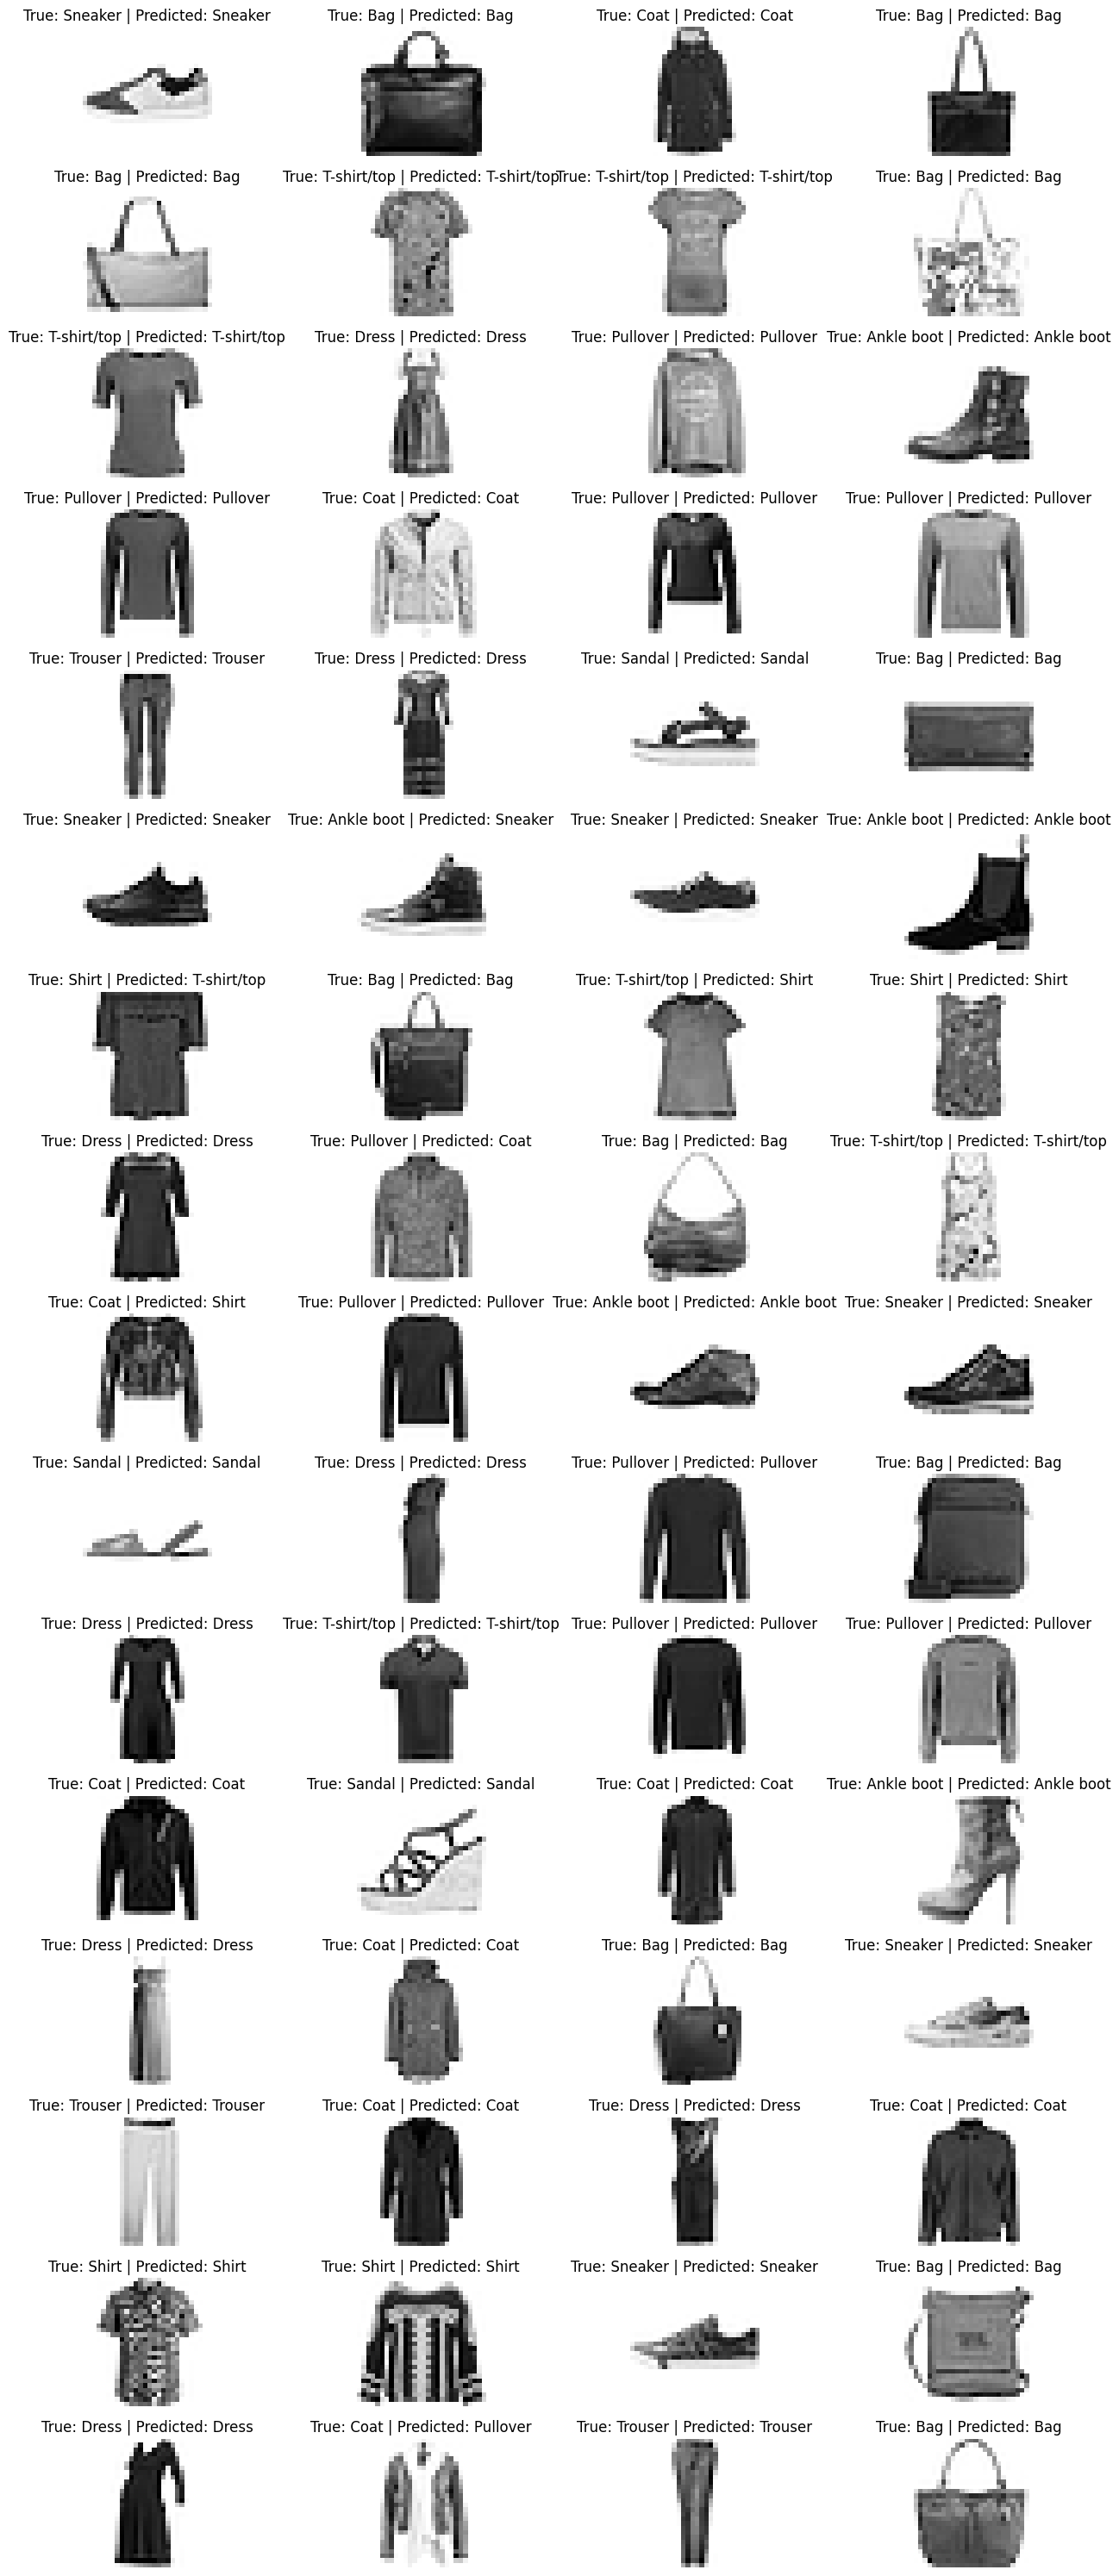

In [25]:
def make_predictions(model, data, device):
  model.to(device)
  model.eval()
  data = torch.stack(data)
  data = data.to(device)
  with torch.inference_mode():
    y_hat_logits = model(data)
    y_hat_preds = torch.argmax(torch.softmax(y_hat_logits, dim=1), dim=1)

  return y_hat_preds


random_images_indices = torch.randint(0, len(test_data), size=(64,))
test_samples = []
test_labels = []
for index in random_images_indices:
  test_data_tuple = test_data[index]
  image, label = test_data_tuple
  test_samples.append(image)
  test_labels.append(label)



y_hat_preds = make_predictions(model2, test_samples, device)

plt.figure(figsize=(14,30))
nrows = math.ceil(int(len(test_samples) / 4))
ncols = 4
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap=plt.cm.Grays)
  plt.title(f"True: {labels_list[test_labels[i]]} | Predicted: {labels_list[y_hat_preds[i]]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
train_dict_model0["neurons_in_linear_layer"] = model0.hidden_units
test_dict_model0["neurons_in_linear_layer"] = model0.hidden_units

print(train_dict_model0)
print(test_dict_model0)

{'model': 'Model0', 'train_loss': 0.38466596371332806, 'train_acc': 86.47666573524475, 'neurons_in_linear_layer': 64}
{'model': 'Model0', 'test_loss': 0.45764242374897, 'test_acc': 84.3500018119812, 'neurons_in_linear_layer': 64}


In [27]:
train_dict_model1["neurons_in_linear_layer"] = model1.hidden_units
test_dict_model1["neurons_in_linear_layer"] = model1.hidden_units
print(train_dict_model1)
print(test_dict_model1)

{'model': 'Model1', 'train_loss': 0.21753393829017878, 'train_acc': 91.9700026512146, 'neurons_in_linear_layer': 64}
{'model': 'Model1', 'test_loss': 0.36281965978145597, 'test_acc': 88.05000185966492, 'neurons_in_linear_layer': 64}


In [28]:
train_dict_model2["neurons_in_linear_layer"] = model2.hidden_units
test_dict_model2["neurons_in_linear_layer"] = model2.hidden_units

print(train_dict_model2)
print(test_dict_model2)

{'model': 'Model2', 'train_loss': 0.19850362376570702, 'train_acc': 92.69833564758301, 'neurons_in_linear_layer': 10}
{'model': 'Model2', 'test_loss': 0.26575425254702567, 'test_acc': 90.85999727249146, 'neurons_in_linear_layer': 10}


### Charts and statistics

In [29]:
list_of_train_dicts = [train_dict_model0, train_dict_model1, train_dict_model2]
list_of_test_dicts = [test_dict_model0, test_dict_model1, test_dict_model2]

model_names = [dictionary["model"] for dictionary in list_of_train_dicts]
train_losses = [dictionary["train_loss"] for dictionary in list_of_train_dicts]
test_losses = [dictionary["test_loss"] for dictionary in list_of_test_dicts]
train_accs = [dictionary["train_acc"] for dictionary in list_of_train_dicts]
test_accs = [dictionary["test_acc"] for dictionary in list_of_test_dicts]
neurons_in_linear_layers = [dictionary["neurons_in_linear_layer"] for dictionary in list_of_train_dicts]

list_of_stats = [train_losses, test_losses, train_accs, test_accs, neurons_in_linear_layers]

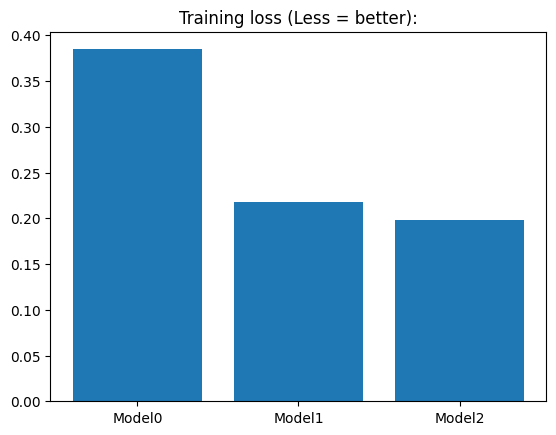

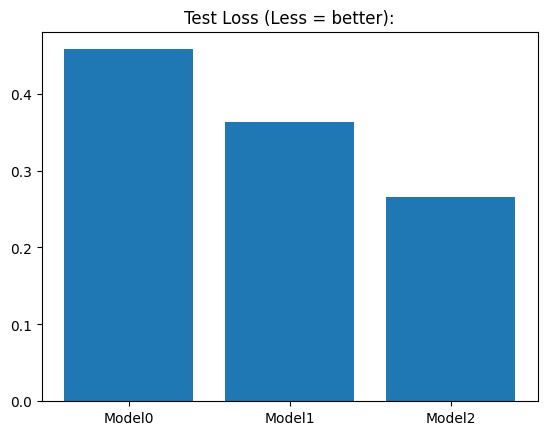

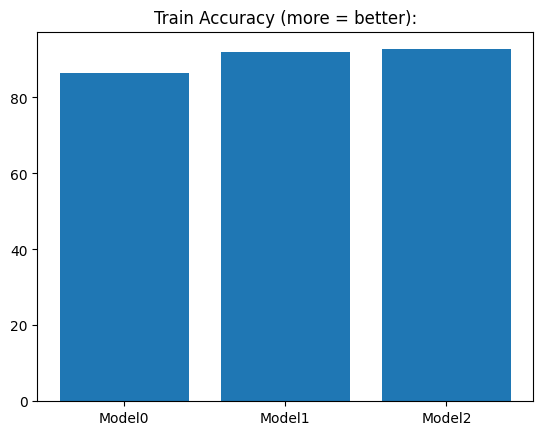

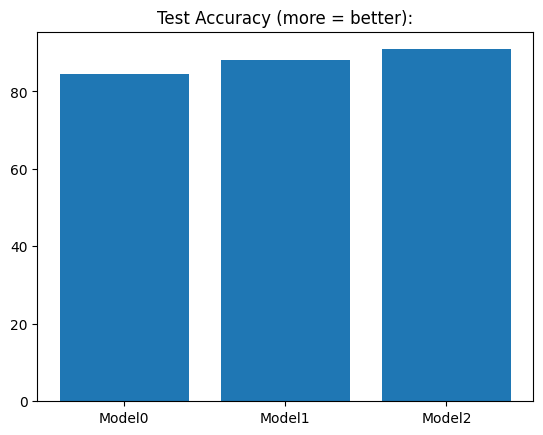

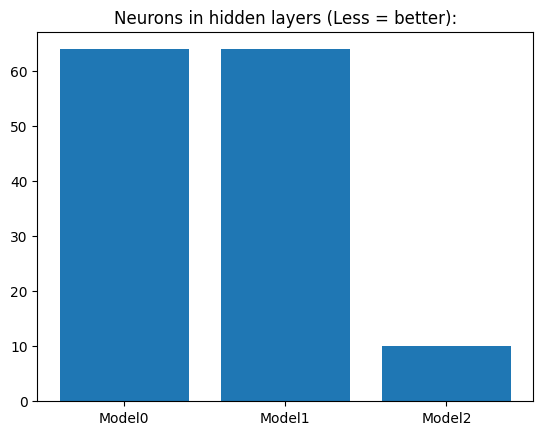

In [30]:
plot_titles = ["Training loss (Less = better):", "Test Loss (Less = better):", "Train Accuracy (more = better):", "Test Accuracy (more = better):", "Neurons in hidden layers (Less = better):"]
for i, list_ in enumerate(list_of_stats):
  data = list_
  plt.bar(x=model_names, height=data)
  plt.title(plot_titles[i])
  plt.show()

### Model 2 seems to be the best in every single stats category. Let's plot confusion matrix for model 2

In [31]:
y_preds_test_list = []
y_true_test_list = []
model2.eval()
for X, y in test_dataloader:
  X, y = X.to(device), y.to(device)
  with torch.inference_mode():
    y_hat_test_logits = model2(X)
    y_hat_test_preds = torch.argmax(torch.softmax(y_hat_test_logits, dim=1), dim=1)
    y_preds_test_list.extend(y_hat_test_preds)
    y_true_test_list.extend(y)

In [32]:
y_preds_test_list = torch.stack(y_preds_test_list)

In [33]:
y_true_test_list = torch.stack(y_true_test_list)

In [34]:
conf_matrix = ConfusionMatrix(task="multiclass", num_classes=len(labels_list)).to(device)
conf_matrix_tensor = conf_matrix(y_preds_test_list, y_true_test_list)

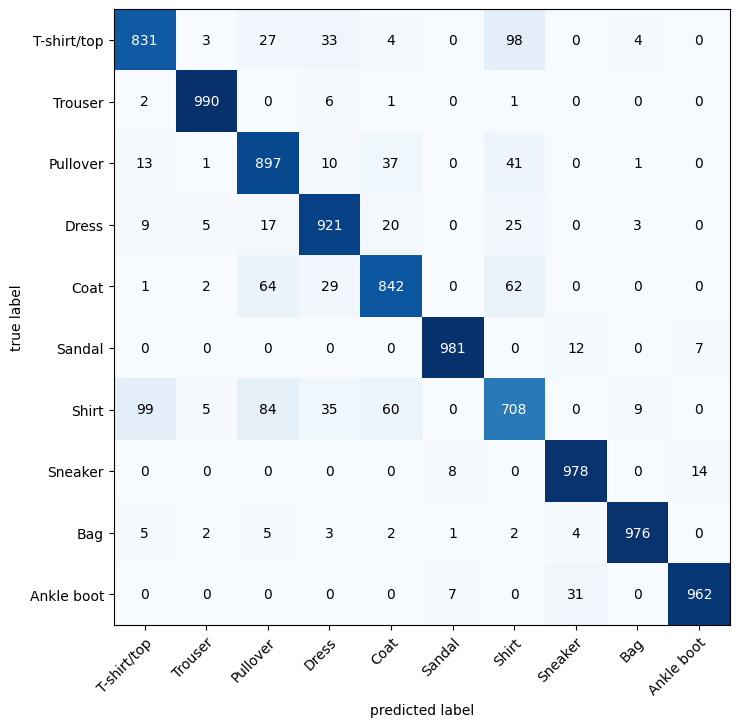

In [35]:
fig, ax = plot_confusion_matrix(conf_mat=conf_matrix_tensor.cpu().numpy(), cmap=plt.cm.Blues, figsize=(8,8), class_names=test_data.classes)

### Inferences

1. Best performing model in terms of accuracy is "Model2", which is built in CNN architecture.
   
2. I chose 20 epochs as the number mutual to all the models. First two models are likely to start overfitting if the number of epochs would be higher 
   
3. Confusion matrix prepared for "Model2" shows that the model classified properly most of the test samples, however it seems like it struggles a bit to distiquish "Shirt" from "T-shirt/top"
   